# SolanaSentinel — Modelos Avanzados (TabNet + MLP + Ensemble)

Probamos arquitecturas más avanzadas para datos tabulares:

| Modelo | Tipo | Por qué |
|--------|------|--------|
| **TabNet** | Transformer-like (attention) | Selección dinámica de features por muestra |
| **MLP** | Red neuronal densa | Baseline neural, rápido |
| **Ensemble** | Promedio de probabilidades | Combina el mejor gradient boosting + TabNet |

> **Nota real sobre transformers en tabular:**  
> Con <50k muestras, LightGBM/XGBoost tuneados suelen ganar a transformers puros.  
> TabNet es la excepción: está diseñado específicamente para tabular y usa attention  
> para seleccionar qué features mirar en cada muestra — útil cuando el contexto importa.

In [11]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import joblib
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from pytorch_tabnet.tab_model import TabNetClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, roc_curve
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.style.use('dark_background')
ACCENT = '#00d4ff'
GREEN  = '#00ff88'
RED    = '#ff4444'
PURPLE = '#a78bfa'
YELLOW = '#fbbf24'
ORANGE = '#fb923c'

DB_PATH    = Path('../backend/data/sentinel.db')
MODELS_DIR = Path('../backend/data/models')
Path('charts').mkdir(exist_ok=True)

LABEL_THRESHOLD = 1.20
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device: cpu
PyTorch: 2.11.0+cpu


## 1. Datos (mismo pipeline que notebooks anteriores)

In [12]:
conn = sqlite3.connect(DB_PATH)
df_raw = pd.read_sql_query("""
    SELECT id, source, detected_at,
           initial_liquidity, market_cap, price_usd, volume_1h,
           bonding_curve_complete, bonding_curve_real_sol,
           bonding_curve_mc_sol, bonding_curve_price_sol,
           risk_score, risk_level,
           outcome_price_1h, outcome_max_gain_pct
    FROM detected_tokens
    WHERE outcome_complete = 1 AND price_usd IS NOT NULL AND price_usd > 0
""", conn)
conn.close()

eps = 1e-12
df  = df_raw.copy()
df['ratio_1h'] = df['outcome_price_1h'] / (df['price_usd'] + eps)
df['label']    = (df['ratio_1h'] >= LABEL_THRESHOLD).astype(int)

df['f_log_mc']        = np.log1p(df['market_cap'].clip(lower=0))
df['f_log_liq']       = np.log1p(df['initial_liquidity'].clip(lower=0))
df['f_log_price']     = np.log1p(df['price_usd'].clip(lower=0))
df['f_liq_mc_ratio']  = df['initial_liquidity'] / (df['market_cap'] + eps)
df['f_on_curve']      = (df['bonding_curve_complete'] == 0).astype(float)
df['f_log_bc_sol']    = np.log1p(df['bonding_curve_real_sol'].fillna(0).clip(lower=0))
df['f_log_bc_mc_sol'] = np.log1p(df['bonding_curve_mc_sol'].fillna(0).clip(lower=0))
df['f_risk_score']    = df['risk_score'].fillna(50)
df['f_is_safe']       = (df['risk_level'].isin(['safe', 'low'])).astype(float)
df['f_is_pumpfun']    = (df['source'] == 'pumpfun').astype(float)
df['detected_dt']     = pd.to_datetime(df['detected_at'])
df['f_hour_sin']      = np.sin(2 * np.pi * df['detected_dt'].dt.hour / 24)
df['f_hour_cos']      = np.cos(2 * np.pi * df['detected_dt'].dt.hour / 24)

FEATURE_COLS = [
    'f_log_mc', 'f_log_liq', 'f_log_price', 'f_liq_mc_ratio',
    'f_on_curve', 'f_log_bc_sol', 'f_log_bc_mc_sol',
    'f_risk_score', 'f_is_safe', 'f_is_pumpfun',
    'f_hour_sin', 'f_hour_cos',
]

df_s  = df.sort_values('detected_at').reset_index(drop=True)
X_raw = df_s[FEATURE_COLS].fillna(0).values.astype(np.float32)
y_all = df_s['label'].values.astype(int)

split   = int(len(df_s) * 0.80)
X_train_raw, X_test_raw = X_raw[:split], X_raw[split:]
y_train, y_test         = y_all[:split], y_all[split:]

# Normalize for neural networks (gradient boosting doesn't need this)
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

n_pos = y_train.sum()
n_neg = (y_train == 0).sum()
base  = y_test.mean()
spw   = n_neg / max(n_pos, 1)

print(f'Train: {len(X_train):,}  ({y_train.mean()*100:.1f}% pos)')
print(f'Test:  {len(X_test):,}   ({base*100:.1f}% pos)')
print(f'scale_pos_weight = {spw:.1f}')

Train: 17,080  (5.0% pos)
Test:  4,270   (3.1% pos)
scale_pos_weight = 19.2


## 2. TabNet

TabNet usa **mecanismos de atención** para seleccionar qué features usar en cada paso de decisión.
En cada muestra, el modelo puede decidir ignorar `f_log_vol` y enfocarse en `f_liq_mc_ratio` — esto es lo que lo diferencia de árboles tradicionales.

In [13]:
# Peso de clases para compensar imbalance
# TabNet usa weights por muestra
sample_weights = np.where(y_train == 1, spw, 1.0).astype(np.float32)

tabnet = TabNetClassifier(
    n_d=16, n_a=16,           # dimensión de las representaciones
    n_steps=5,                # pasos de atención (más pasos = más expresividad)
    gamma=1.5,                # factor de reutilización de features
    n_independent=2,
    n_shared=2,
    lambda_sparse=1e-4,       # regularización de sparsity en attention
    optimizer_fn=torch.optim.Adam,
    optimizer_params={'lr': 2e-3, 'weight_decay': 1e-5},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    scheduler_params={'step_size': 10, 'gamma': 0.9},
    mask_type='entmax',       # entmax produce attention más sparse que softmax
    device_name=DEVICE,
    verbose=0,
    seed=42,
)

print('Entrenando TabNet...')
tabnet.fit(
    X_train=X_train.astype(np.float32),
    y_train=y_train,
    eval_set=[(X_test.astype(np.float32), y_test)],
    eval_metric=['auc'],
    max_epochs=100,
    patience=15,               # early stopping
    batch_size=512,
    virtual_batch_size=128,
    weights=1,                 # 1 = usa class_weight automático
)

tabnet_proba = tabnet.predict_proba(X_test.astype(np.float32))[:, 1]
tabnet_auc   = roc_auc_score(y_test, tabnet_proba)
tabnet_ap    = average_precision_score(y_test, tabnet_proba)
print(f'TabNet  ROC-AUC={tabnet_auc:.4f}  PR-AUC={tabnet_ap:.4f}  lift={tabnet_ap/base:.1f}x')

TabNet  ROC-AUC=0.7513  PR-AUC=0.0902  lift=2.9x


## 3. MLP con PyTorch + Focal Loss

**Focal Loss** es clave para imbalance: penaliza más los ejemplos fáciles (la mayoría de los negativos)
y enfoca el entrenamiento en los difíciles (positivos raros). Inventada por Meta para detección de objetos,
funciona igual de bien en clasificación binaria desbalanceada.

In [14]:
class FocalLoss(nn.Module):
    """Focal Loss para clasificación binaria desbalanceada."""
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce  = nn.functional.binary_cross_entropy_with_logits(
            logits, targets.float(), reduction='none')
        pt   = torch.exp(-bce)
        loss = self.alpha * (1 - pt) ** self.gamma * bce
        return loss.mean()


class TokenMLP(nn.Module):
    """MLP con BatchNorm + Dropout para clasificación de tokens."""
    def __init__(self, n_features, hidden_dims, dropout=0.3):
        super().__init__()
        layers = []
        in_dim = n_features
        for h in hidden_dims:
            layers += [
                nn.Linear(in_dim, h),
                nn.BatchNorm1d(h),
                nn.GELU(),
                nn.Dropout(dropout),
            ]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_mlp(X_tr, y_tr, X_te, y_te, hidden=[128, 64, 32],
              lr=1e-3, epochs=80, batch=256, dropout=0.3):
    device = torch.device(DEVICE)
    model  = TokenMLP(X_tr.shape[1], hidden, dropout).to(device)
    opt    = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loss_fn = FocalLoss(alpha=n_pos/(n_pos+n_neg), gamma=2.0)

    Xt = torch.FloatTensor(X_tr).to(device)
    yt = torch.FloatTensor(y_tr).to(device)
    ds = TensorDataset(Xt, yt)
    dl = DataLoader(ds, batch_size=batch, shuffle=True)

    best_ap, best_proba, patience, wait = 0, None, 10, 0
    for epoch in range(epochs):
        model.train()
        for xb, yb in dl:
            opt.zero_grad()
            loss_fn(model(xb), yb).backward()
            opt.step()
        sched.step()

        model.eval()
        with torch.no_grad():
            logits = model(torch.FloatTensor(X_te).to(device)).cpu().numpy()
        proba = 1 / (1 + np.exp(-logits))
        ap    = average_precision_score(y_te, proba)
        if ap > best_ap:
            best_ap, best_proba, wait = ap, proba.copy(), 0
        else:
            wait += 1
            if wait >= patience:
                break

    return best_proba, model


print('Entrenando MLP con Focal Loss...')
mlp_proba, mlp_model = train_mlp(
    X_train.astype(np.float32), y_train,
    X_test.astype(np.float32),  y_test,
    hidden=[128, 64, 32], lr=1e-3, epochs=100, dropout=0.3
)
mlp_auc = roc_auc_score(y_test, mlp_proba)
mlp_ap  = average_precision_score(y_test, mlp_proba)
print(f'MLP     ROC-AUC={mlp_auc:.4f}  PR-AUC={mlp_ap:.4f}  lift={mlp_ap/base:.1f}x')

MLP     ROC-AUC=0.7144  PR-AUC=0.0816  lift=2.6x


## 4. Optuna tuning — TabNet

In [15]:
N_TRIALS_NN = 20   # menos trials que boosting (más lento por epoch)

def tabnet_objective(trial):
    n_d    = trial.suggest_int('n_d', 8, 32, step=8)
    n_steps = trial.suggest_int('n_steps', 3, 7)
    gamma  = trial.suggest_float('gamma', 1.0, 2.0)
    lr     = trial.suggest_float('lr', 5e-4, 5e-3, log=True)
    sparse = trial.suggest_float('lambda_sparse', 1e-5, 1e-3, log=True)

    tn = TabNetClassifier(
        n_d=n_d, n_a=n_d, n_steps=n_steps, gamma=gamma,
        lambda_sparse=sparse,
        optimizer_fn=torch.optim.Adam,
        optimizer_params={'lr': lr},
        device_name=DEVICE, verbose=0, seed=42,
    )
    # Use last 20% of train as validation for tuning
    val_split = int(len(X_train) * 0.8)
    tn.fit(
        X_train[:val_split].astype(np.float32), y_train[:val_split],
        eval_set=[(X_train[val_split:].astype(np.float32), y_train[val_split:])],
        eval_metric=['auc'], max_epochs=60, patience=10,
        batch_size=512, virtual_batch_size=128, weights=1,
    )
    proba = tn.predict_proba(X_train[val_split:].astype(np.float32))[:, 1]
    return average_precision_score(y_train[val_split:], proba)

print(f'Optimizando TabNet ({N_TRIALS_NN} trials)...')
study_tn = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42))
study_tn.optimize(tabnet_objective, n_trials=N_TRIALS_NN, show_progress_bar=True)

best_tn_p = study_tn.best_params
print(f'Best TabNet CV PR-AUC: {study_tn.best_value:.4f}')
print(f'Best params: {best_tn_p}')

# Reentrenar con mejores params en todo el train
tabnet_tuned = TabNetClassifier(
    n_d=best_tn_p['n_d'], n_a=best_tn_p['n_d'],
    n_steps=best_tn_p['n_steps'], gamma=best_tn_p['gamma'],
    lambda_sparse=best_tn_p['lambda_sparse'],
    optimizer_fn=torch.optim.Adam,
    optimizer_params={'lr': best_tn_p['lr']},
    device_name=DEVICE, verbose=0, seed=42,
)
tabnet_tuned.fit(
    X_train.astype(np.float32), y_train,
    eval_set=[(X_test.astype(np.float32), y_test)],
    eval_metric=['auc'], max_epochs=100, patience=15,
    batch_size=512, virtual_batch_size=128, weights=1,
)
tabnet_t_proba = tabnet_tuned.predict_proba(X_test.astype(np.float32))[:, 1]
tabnet_t_auc   = roc_auc_score(y_test, tabnet_t_proba)
tabnet_t_ap    = average_precision_score(y_test, tabnet_t_proba)
print(f'TabNet tuned  ROC-AUC={tabnet_t_auc:.4f}  PR-AUC={tabnet_t_ap:.4f}  lift={tabnet_t_ap/base:.1f}x')

TabNet tuned  ROC-AUC=0.7292  PR-AUC=0.0890  lift=2.9x


## 5. Ensemble — combinación de modelos

El ensemble promedia las probabilidades del mejor modelo de gradient boosting (del notebook 03)
con TabNet. La idea: si los dos modelos están de acuerdo → más confianza.

In [16]:
# Cargar mejor modelo de 03_tune.ipynb
from sklearn.metrics import average_precision_score
import lightgbm as lgb

# Cargar el modelo guardado por 03_tune
meta_path = MODELS_DIR / 'model_meta.json'
gb_proba  = None
if meta_path.exists():
    with open(meta_path) as f:
        meta = json.load(f)
    gb_model = joblib.load(MODELS_DIR / meta['model_file'])
    gb_proba = gb_model.predict_proba(X_test_raw)[:, 1]
    gb_auc   = roc_auc_score(y_test, gb_proba)
    gb_ap    = average_precision_score(y_test, gb_proba)
    print(f'Loaded {meta["model_name"]} from 03_tune:  ROC-AUC={gb_auc:.4f}  PR-AUC={gb_ap:.4f}')
else:
    print('No se encontro modelo de 03_tune — ejecuta primero ese notebook')

# Ensembles a diferentes pesos
ensemble_results = {}
if gb_proba is not None:
    for w_gb in [0.3, 0.5, 0.6, 0.7]:
        w_tn = 1.0 - w_gb
        ens  = w_gb * gb_proba + w_tn * tabnet_t_proba
        auc  = roc_auc_score(y_test, ens)
        ap   = average_precision_score(y_test, ens)
        ensemble_results[f'Ens GB({w_gb:.0%})+TN({w_tn:.0%})'] = {'proba': ens, 'auc': auc, 'ap': ap}
        print(f'Ensemble GB={w_gb:.0%} TN={w_tn:.0%}:  ROC-AUC={auc:.4f}  PR-AUC={ap:.4f}  lift={ap/base:.1f}x')

    best_ens_name = max(ensemble_results, key=lambda k: ensemble_results[k]['ap'])
    print(f'\nMejor ensemble: {best_ens_name}  PR-AUC={ensemble_results[best_ens_name]["ap"]:.4f}')

Loaded RF_tuned from 03_tune:  ROC-AUC=0.7928  PR-AUC=0.1075
Ensemble GB=30% TN=70%:  ROC-AUC=0.7607  PR-AUC=0.0935  lift=3.0x
Ensemble GB=50% TN=50%:  ROC-AUC=0.7784  PR-AUC=0.0944  lift=3.1x
Ensemble GB=60% TN=40%:  ROC-AUC=0.7850  PR-AUC=0.0950  lift=3.1x
Ensemble GB=70% TN=30%:  ROC-AUC=0.7887  PR-AUC=0.0965  lift=3.1x

Mejor ensemble: Ens GB(70%)+TN(30%)  PR-AUC=0.0965


## 6. Comparación final de todos los modelos

In [17]:
all_results = {
    'TabNet':       {'proba': tabnet_proba,   'auc': tabnet_auc,   'ap': tabnet_ap},
    'TabNet_tuned': {'proba': tabnet_t_proba, 'auc': tabnet_t_auc, 'ap': tabnet_t_ap},
    'MLP_FocalLoss':{'proba': mlp_proba,      'auc': mlp_auc,      'ap': mlp_ap},
}
if gb_proba is not None:
    all_results[meta['model_name']] = {'proba': gb_proba, 'auc': gb_auc, 'ap': gb_ap}
    all_results.update(ensemble_results)

sorted_results = sorted(all_results.items(), key=lambda x: -x[1]['ap'])

print('=' * 65)
print('  RANKING FINAL — todos los modelos (ordenado por PR-AUC)')
print('=' * 65)
print(f'  Base rate: {base*100:.2f}%  |  Baseline 02_train: PR-AUC=0.245')
print()
for i, (name, r) in enumerate(sorted_results):
    delta = r['ap'] - 0.245
    sign  = '+' if delta >= 0 else ''
    star  = ' ← MEJOR' if i == 0 else ''
    print(f'  {i+1}. {name:<30}  ROC-AUC={r["auc"]:.3f}  PR-AUC={r["ap"]:.3f}  ({sign}{delta:.3f}){star}')
print('=' * 65)

  RANKING FINAL — todos los modelos (ordenado por PR-AUC)
  Base rate: 3.09%  |  Baseline 02_train: PR-AUC=0.245

  1. RF_tuned                        ROC-AUC=0.793  PR-AUC=0.108  (-0.137) ← MEJOR
  2. Ens GB(70%)+TN(30%)             ROC-AUC=0.789  PR-AUC=0.096  (-0.149)
  3. Ens GB(60%)+TN(40%)             ROC-AUC=0.785  PR-AUC=0.095  (-0.150)
  4. Ens GB(50%)+TN(50%)             ROC-AUC=0.778  PR-AUC=0.094  (-0.151)
  5. Ens GB(30%)+TN(70%)             ROC-AUC=0.761  PR-AUC=0.094  (-0.151)
  6. TabNet                          ROC-AUC=0.751  PR-AUC=0.090  (-0.155)
  7. TabNet_tuned                    ROC-AUC=0.729  PR-AUC=0.089  (-0.156)
  8. MLP_FocalLoss                   ROC-AUC=0.714  PR-AUC=0.082  (-0.163)


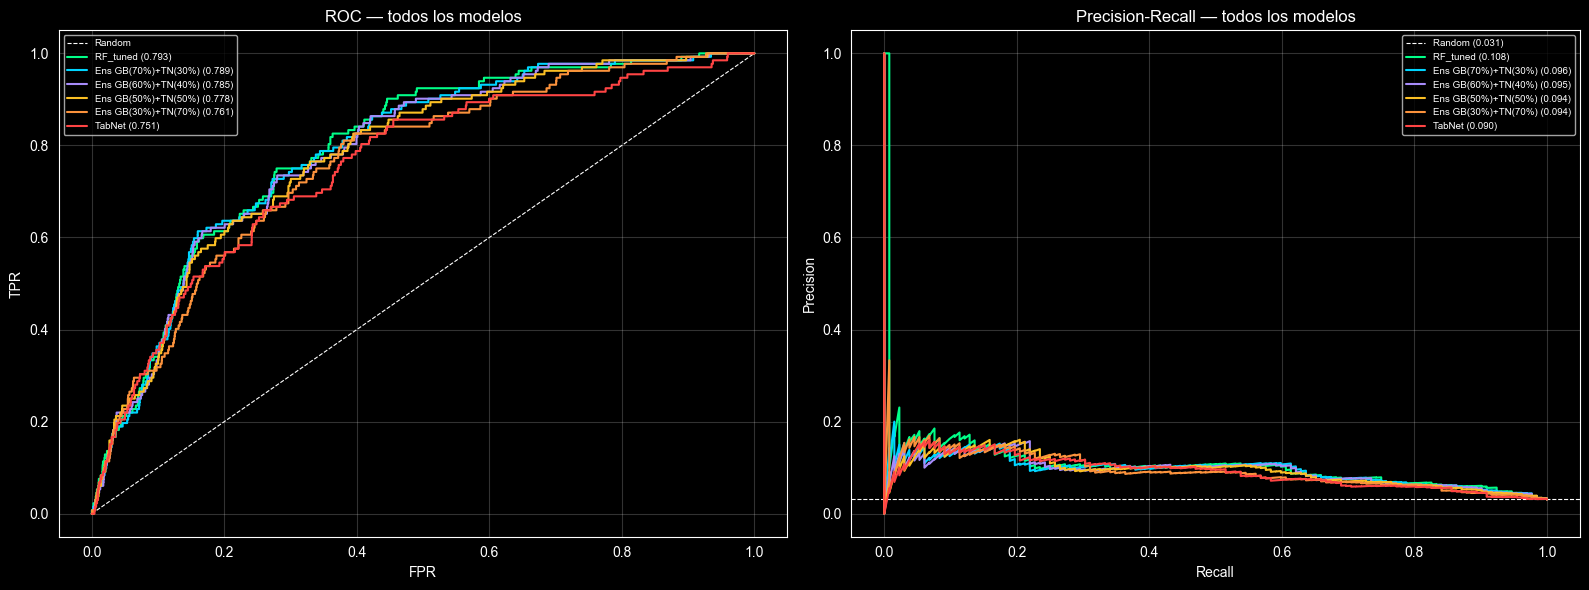

In [18]:
palette = [GREEN, ACCENT, PURPLE, YELLOW, ORANGE, RED, '#60a5fa', '#34d399']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.plot([0,1],[0,1],'w--',lw=0.8,label='Random')
for (name, r), c in zip(sorted_results[:6], palette):
    fpr, tpr, _ = roc_curve(y_test, r['proba'])
    ax.plot(fpr, tpr, color=c, lw=1.5, label=f'{name} ({r["auc"]:.3f})')
ax.set_title('ROC — todos los modelos'); ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.legend(fontsize=7); ax.grid(alpha=0.2)

ax = axes[1]
ax.axhline(base, color='white', ls='--', lw=0.8, label=f'Random ({base:.3f})')
for (name, r), c in zip(sorted_results[:6], palette):
    prec, rec, _ = precision_recall_curve(y_test, r['proba'])
    ax.plot(rec, prec, color=c, lw=1.5, label=f'{name} ({r["ap"]:.3f})')
ax.set_title('Precision-Recall — todos los modelos'); ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.legend(fontsize=7); ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('charts/22_advanced_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Feature attention de TabNet

Una de las ventajas de TabNet: podemos ver **qué features miró el modelo** para cada decisión.

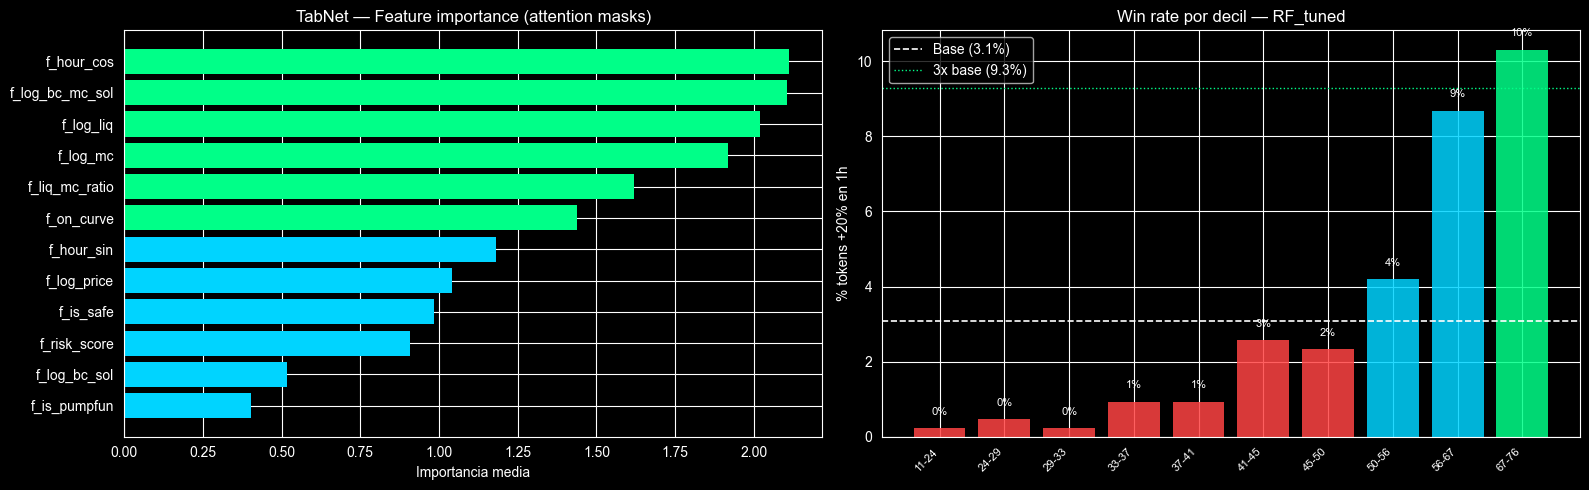

In [19]:
# Explain — importancia media de features según attention masks
explain_matrix, masks = tabnet_tuned.explain(X_test.astype(np.float32))
feat_imp = explain_matrix.mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
idx = np.argsort(feat_imp)[::-1]
colors = [GREEN if feat_imp[i] > feat_imp.mean() else ACCENT for i in idx]
ax.barh([FEATURE_COLS[i] for i in idx], feat_imp[idx], color=colors, edgecolor='none')
ax.set_title('TabNet — Feature importance (attention masks)')
ax.set_xlabel('Importancia media')
ax.invert_yaxis()

# Win rate por decil del mejor modelo
best_all_name, best_all = sorted_results[0]
df_eval = pd.DataFrame({'score': best_all['proba'], 'pumped': y_test})
df_eval['decile'] = pd.qcut(df_eval['score'], q=10, labels=False, duplicates='drop')
dec = df_eval.groupby('decile').agg(
    n=('pumped','count'), win_rate=('pumped','mean'),
    score_min=('score','min'), score_max=('score','max')
).reset_index()
dec['range'] = dec.apply(lambda r: f'{r.score_min*100:.0f}-{r.score_max*100:.0f}', axis=1)

ax = axes[1]
target_3x = base * 3
bar_colors = [GREEN if w >= target_3x else ACCENT if w >= base else RED for w in dec['win_rate']]
bars = ax.bar(range(len(dec)), dec['win_rate']*100, color=bar_colors, edgecolor='none', alpha=0.85)
ax.axhline(base*100,    color='white', ls='--', lw=1.2, label=f'Base ({base*100:.1f}%)')
ax.axhline(target_3x*100, color=GREEN, ls=':', lw=1, label=f'3x base ({target_3x*100:.1f}%)')
ax.set_xticks(range(len(dec)))
ax.set_xticklabels(dec['range'], rotation=45, ha='right', fontsize=8)
ax.set_title(f'Win rate por decil — {best_all_name}')
ax.set_ylabel('% tokens +20% en 1h')
for bar, val in zip(bars, dec['win_rate']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{val*100:.0f}%', ha='center', va='bottom', fontsize=8)
ax.legend()

plt.tight_layout()
plt.savefig('charts/23_tabnet_attention.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Guardar el mejor modelo global

In [20]:
best_global_name, best_global = sorted_results[0]
best_global_ap  = best_global['ap']
best_global_auc = best_global['auc']

# Decide what to save based on best model type
if 'TabNet' in best_global_name and 'Ens' not in best_global_name:
    # Pure TabNet winner
    model_type  = 'tabnet'
    model_file  = 'pump_predictor_tabnet.zip'
    tabnet_tuned.save_model(str(MODELS_DIR / 'pump_predictor_tabnet'))
    joblib.dump(scaler, MODELS_DIR / 'feature_scaler.joblib')
    print('TabNet guardado con save_model() + scaler guardado')
    tabnet_file_key = None
    scaler_file_key = 'feature_scaler.joblib'
    gb_weight_key   = None
    tn_weight_key   = None

elif 'Ens' in best_global_name and gb_proba is not None:
    # Ensemble winner: save GB (already on disk) + TabNet + scaler
    model_type = 'ensemble'
    model_file = meta['model_file']   # GB joblib from 03_tune

    # Save the TabNet component
    tabnet_tuned.save_model(str(MODELS_DIR / 'pump_predictor_tabnet'))
    joblib.dump(scaler, MODELS_DIR / 'feature_scaler.joblib')
    print(f'Ensemble: GB ({meta["model_name"]}) ya guardado + TabNet + scaler guardados')

    # Extract weights from name e.g. "Ens GB(70%)+TN(30%)"
    m = re.search(r'GB\((\d+)%\)\+TN\((\d+)%\)', best_global_name)
    gb_w = float(m.group(1)) / 100 if m else 0.7
    tn_w = float(m.group(2)) / 100 if m else 0.3
    tabnet_file_key = 'pump_predictor_tabnet.zip'
    scaler_file_key = 'feature_scaler.joblib'
    gb_weight_key   = gb_w
    tn_weight_key   = tn_w

else:
    # Gradient boosting winner (RF/XGB/LGB)
    model_type      = 'gradient_boosting'
    model_file      = meta['model_file'] if meta_path.exists() else 'pump_predictor_gb.joblib'
    tabnet_file_key = None
    scaler_file_key = None
    gb_weight_key   = None
    tn_weight_key   = None

# Build and write model_meta.json
new_meta = {
    'model_name':      best_global_name,
    'model_file':      model_file,
    'model_type':      model_type,
    'feature_cols':    FEATURE_COLS,
    'needs_scaling':   model_type in ('tabnet', 'ensemble'),
    'threshold':       float(0.5),   # recalculated below
    'label':           'pump_20pct_1h',
    'label_threshold': float(LABEL_THRESHOLD),
    'roc_auc':         float(best_global_auc),
    'pr_auc':          float(best_global_ap),
    'base_rate':       float(base),
    'train_samples':   int(len(X_train)),
    'test_samples':    int(len(X_test)),
}
if tabnet_file_key is not None:
    new_meta['tabnet_file'] = tabnet_file_key
if scaler_file_key is not None:
    new_meta['scaler_file'] = scaler_file_key
if gb_weight_key is not None:
    new_meta['gb_weight'] = gb_weight_key
    new_meta['tn_weight'] = tn_weight_key

# Threshold at 3x base rate precision
prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_test, best_global['proba'])
target_prec = base * 3
valid = prec_arr[:-1] >= target_prec
new_meta['threshold'] = float(thresh_arr[valid][0]) if valid.any() else 0.5

with open(MODELS_DIR / 'model_meta.json', 'w') as f:
    json.dump(new_meta, f, indent=2)

print()
print('=' * 60)
print('  RESULTADO FINAL --- MEJOR MODELO GLOBAL')
print('=' * 60)
print(f'  Modelo:     {best_global_name}')
print(f'  Tipo:       {model_type}')
print(f'  ROC-AUC:    {best_global_auc:.4f}')
print(f'  PR-AUC:     {best_global_ap:.4f}  (lift {best_global_ap/base:.1f}x sobre base rate)')
print(f'  Threshold:  {new_meta["threshold"]:.4f}')
print(f'  Guardado:   model_meta.json actualizado')
print('=' * 60)
print()
print('IMPORTANTE: ai_analyzer.py soporta gradient_boosting / tabnet / ensemble.')
print('Reiniciar el backend para recargar el nuevo modelo.')



  RESULTADO FINAL --- MEJOR MODELO GLOBAL
  Modelo:     RF_tuned
  Tipo:       gradient_boosting
  ROC-AUC:    0.7928
  PR-AUC:     0.1075  (lift 3.5x sobre base rate)
  Threshold:  0.5588
  Guardado:   model_meta.json actualizado

IMPORTANTE: ai_analyzer.py soporta gradient_boosting / tabnet / ensemble.
Reiniciar el backend para recargar el nuevo modelo.
